In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

data = pd.read_csv("student_habits_performance.csv")

print("Shape:", data.shape)
data.head()

Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [2]:
print("Shape:", data.shape)

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

print("\nNumerical summary:")
print(data.describe())

Shape: (1000, 16)

Data types:
student_id                           str
age                                int64
gender                               str
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                        str
attendance_percentage            float64
sleep_hours                      float64
diet_quality                         str
exercise_frequency                 int64
parental_education_level             str
internet_quality                     str
mental_health_rating               int64
extracurricular_participation        str
exam_score                       float64
dtype: object

Missing values:
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage         

In [3]:
study_limit = (150096724135 % 5) + 1

male_data = data[
    (data["gender"] == "Male") &
    (data["study_hours_per_day"] >= study_limit)
].copy()

print("Roll number mod 5:", 150096724135 % 5)
print("Study-hours limit:", study_limit)
print("Male + study limit rows:", len(male_data))

if len(male_data) < 150:
    parth_data = data[data["gender"] == "Male"].copy()
    print("Fewer than 150 rows, so study-hours condition was removed.")
else:
    parth_data = male_data.copy()
    print("Study-hours condition was retained.")

print("Final personalized rows:", len(parth_data))
print("\nGender:")
print(parth_data["gender"].value_counts())

Roll number mod 5: 0
Study-hours limit: 1
Male + study limit rows: 456
Study-hours condition was retained.
Final personalized rows: 456

Gender:
gender
Male    456
Name: count, dtype: int64


In [4]:
print("Personalization check")
print("--------------------")
print("All rows are male:", (parth_data["gender"] == "Male").all())

if len(male_data) >= 150:
    print(
        "All rows satisfy study-hours >= 1:",
        (parth_data["study_hours_per_day"] >= 1).all()
    )
else:
    print("Fallback used: gender-only filter")

print("Number of rows:", len(parth_data))

Personalization check
--------------------
All rows are male: True
All rows satisfy study-hours >= 1: True
Number of rows: 456


In [5]:
parth_data = parth_data.drop_duplicates().copy()

parth_data["study_hours_per_day"] = pd.to_numeric(
    parth_data["study_hours_per_day"],
    errors="coerce"
)

parth_data["sleep_hours"] = pd.to_numeric(
    parth_data["sleep_hours"],
    errors="coerce"
)

parth_data["exam_score"] = pd.to_numeric(
    parth_data["exam_score"],
    errors="coerce"
)

for col in parth_data.select_dtypes(include="object").columns:
    parth_data[col] = parth_data[col].fillna(
        parth_data[col].mode()[0]
    )

for col in parth_data.select_dtypes(exclude="object").columns:
    parth_data[col] = parth_data[col].fillna(
        parth_data[col].median()
    )

q1_score = parth_data["exam_score"].quantile(0.25)
q3_score = parth_data["exam_score"].quantile(0.75)
iqr_score = q3_score - q1_score

q1_study = parth_data["study_hours_per_day"].quantile(0.25)
q3_study = parth_data["study_hours_per_day"].quantile(0.75)
iqr_study = q3_study - q1_study

score_outliers = parth_data[
    (parth_data["exam_score"] < q1_score - 1.5 * iqr_score) |
    (parth_data["exam_score"] > q3_score + 1.5 * iqr_score)
]

study_outliers = parth_data[
    (parth_data["study_hours_per_day"] < q1_study - 1.5 * iqr_study) |
    (parth_data["study_hours_per_day"] > q3_study + 1.5 * iqr_study)
]

print("Shape after cleaning:", parth_data.shape)
print("\nMissing values after cleaning:")
print(parth_data.isnull().sum())

print("\nDuplicate rows after cleaning:", parth_data.duplicated().sum())

print("\nExam score outliers:", len(score_outliers))
print("Study hours outliers:", len(study_outliers))

Shape after cleaning: (456, 16)

Missing values after cleaning:
student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

Duplicate rows after cleaning: 0

Exam score outliers: 0
Study hours outliers: 4


/var/folders/rr/t6xy46wn3xjb_5ftmgsh_m8m0000gn/T/ipykernel_93295/3815585849.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in parth_data.select_dtypes(include="object").columns:


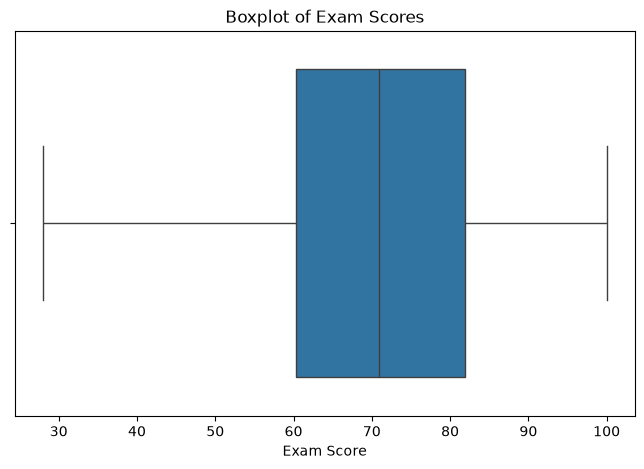

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x=parth_data["exam_score"])
plt.xlabel("Exam Score")
plt.title("Boxplot of Exam Scores")
plt.show()

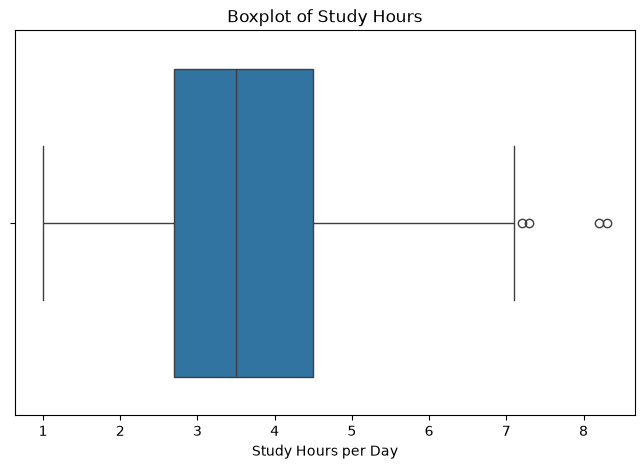

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x=parth_data["study_hours_per_day"])
plt.xlabel("Study Hours per Day")
plt.title("Boxplot of Study Hours")
plt.show()

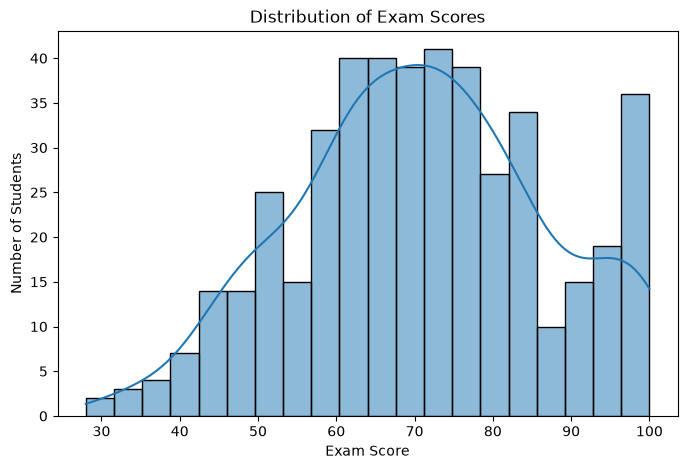

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    parth_data["exam_score"],
    bins=20,
    kde=True
)

plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")

plt.show()

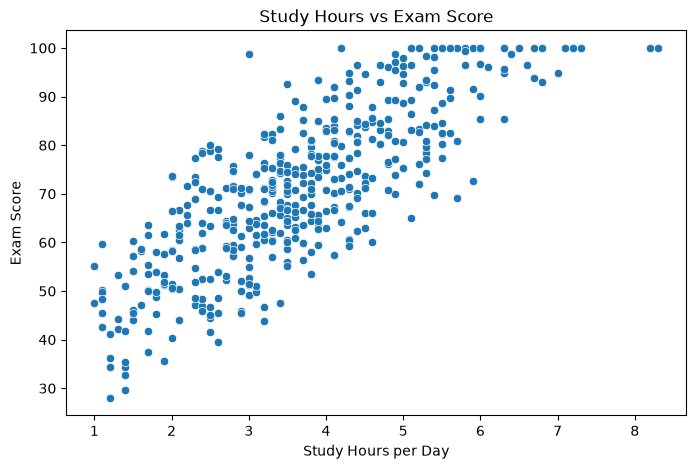

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=parth_data,
    x="study_hours_per_day",
    y="exam_score"
)

plt.xlabel("Study Hours per Day")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")

plt.show()

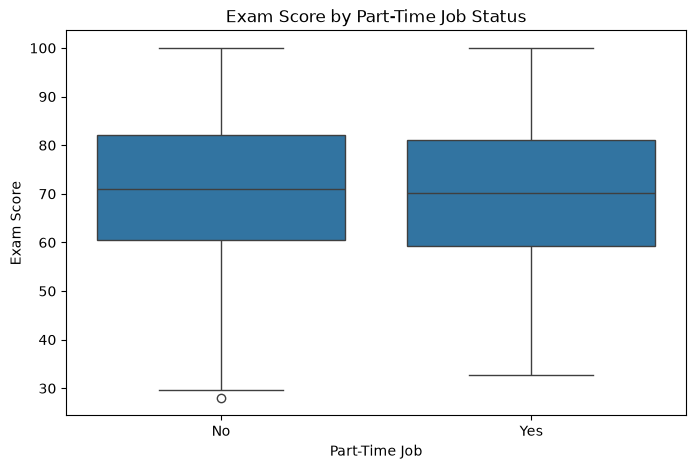

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=parth_data,
    x="part_time_job",
    y="exam_score"
)

plt.xlabel("Part-Time Job")
plt.ylabel("Exam Score")
plt.title("Exam Score by Part-Time Job Status")

plt.show()

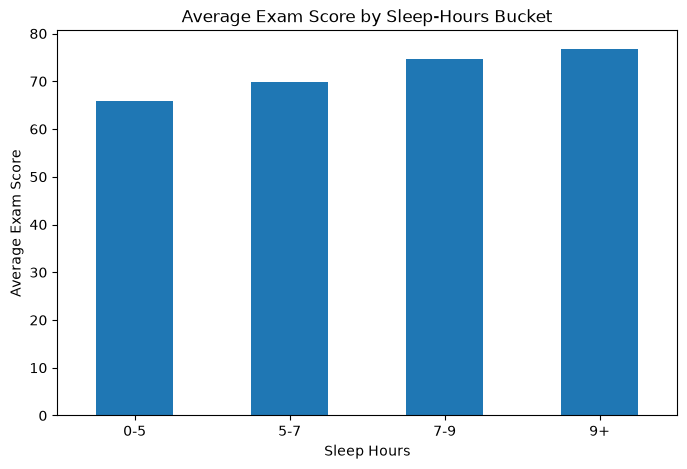

In [11]:
parth_data["sleep_bucket"] = pd.cut(
    parth_data["sleep_hours"],
    bins=[0, 5, 7, 9, 24],
    labels=["0-5", "5-7", "7-9", "9+"],
    include_lowest=True
)

avg_score_sleep = parth_data.groupby(
    "sleep_bucket",
    observed=False
)["exam_score"].mean()

plt.figure(figsize=(8,5))

avg_score_sleep.plot(kind="bar")

plt.xlabel("Sleep Hours")
plt.ylabel("Average Exam Score")
plt.title("Average Exam Score by Sleep-Hours Bucket")

plt.xticks(rotation=0)

plt.show()

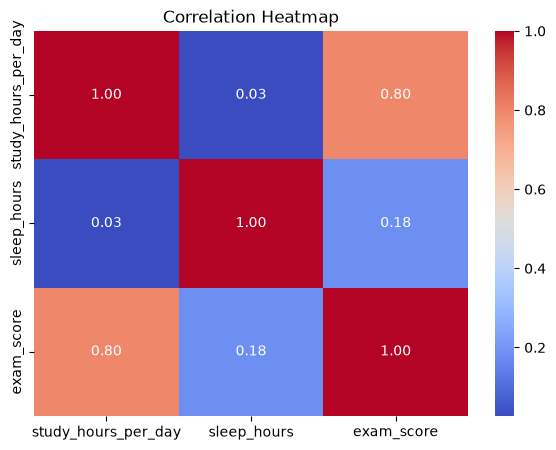

In [12]:
corr = parth_data[
    [
        "study_hours_per_day",
        "sleep_hours",
        "exam_score"
    ]
].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [34]:
X = parth_data[
    [
        "study_hours_per_day",
        "sleep_hours",
        "attendance_percentage",
        "social_media_hours",
        "netflix_hours"
    ]
]

y = parth_data["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (364, 5)
Testing data: (92, 5)


In [35]:
model = LinearRegression()

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

print("Baseline Linear Regression")
print("--------------------------")
print("Train R-squared:", train_r2)
print("Test R-squared:", test_r2)
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Baseline Linear Regression
--------------------------
Train R-squared: 0.7369208776340215
Test R-squared: 0.6703962199071829
Train RMSE: 8.176353969627897
Test RMSE: 9.146332625642643


In [37]:
features = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours",
    "netflix_hours",
    "age",
    "mental_health_rating",
    "exercise_frequency",
    "part_time_job",
    "diet_quality",
    "internet_quality",
    "parental_education_level",
    "extracurricular_participation"
]

X = parth_data[features]
y = parth_data["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

numeric_features = [
    "study_hours_per_day",
    "sleep_hours",
    "attendance_percentage",
    "social_media_hours",
    "netflix_hours",
    "age",
    "mental_health_rating",
    "exercise_frequency"
]

categorical_features = [
    "part_time_job",
    "diet_quality",
    "internet_quality",
    "parental_education_level",
    "extracurricular_participation"
]

preprocessor = ColumnTransformer(
    [
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

improved_model_v2 = make_pipeline(
    preprocessor,
    LinearRegression()
)

improved_model_v2.fit(X_train, y_train)

train_pred_v2 = improved_model_v2.predict(X_train)
test_pred_v2 = improved_model_v2.predict(X_test)

train_r2_v2 = r2_score(y_train, train_pred_v2)
test_r2_v2 = r2_score(y_test, test_pred_v2)

train_rmse_v2 = np.sqrt(
    mean_squared_error(y_train, train_pred_v2)
)

test_rmse_v2 = np.sqrt(
    mean_squared_error(y_test, test_pred_v2)
)

print("Improved Linear Regression V2")
print("-----------------------------")
print("Train R-squared:", train_r2_v2)
print("Test R-squared:", test_r2_v2)
print("Train RMSE:", train_rmse_v2)
print("Test RMSE:", test_rmse_v2)

Improved Linear Regression V2
-----------------------------
Train R-squared: 0.8946052142885083
Test R-squared: 0.8978022632878274
Train RMSE: 5.175187093223011
Test RMSE: 5.092974930669041


In [43]:
feature_corr = parth_data[
    [
        "study_hours_per_day",
        "sleep_hours",
        "attendance_percentage",
        "social_media_hours",
        "netflix_hours",
        "exam_score"
    ]
].corr()["exam_score"].sort_values()

print(feature_corr)

netflix_hours           -0.186238
social_media_hours      -0.141861
attendance_percentage    0.103451
sleep_hours              0.179783
study_hours_per_day      0.796703
exam_score               1.000000
Name: exam_score, dtype: float64


In [48]:
print("MODEL ITERATION COMPARISON")
print("==========================")

print("\nBaseline Model")
print("Test R-squared:", test_r2)
print("Test RMSE:", test_rmse)

print("\nImproved V2 Model")
print("Train R-squared:", train_r2_v2)
print("Test R-squared:", test_r2_v2)
print("Train RMSE:", train_rmse_v2)
print("Test RMSE:", test_rmse_v2)

MODEL ITERATION COMPARISON

Baseline Model
Test R-squared: 0.6703962199071829
Test RMSE: 9.146332625642643

Improved V2 Model
Train R-squared: 0.8946052142885083
Test R-squared: 0.8978022632878274
Train RMSE: 5.175187093223011
Test RMSE: 5.092974930669041


In [49]:
print("FINAL MODEL")
print("-----------")

print("Train R-squared:", train_r2_v2)
print("Test R-squared:", test_r2_v2)

print("Train RMSE:", train_rmse_v2)
print("Test RMSE:", test_rmse_v2)

print("Rows used:", len(parth_data))
print("Gender used:", parth_data["gender"].unique())

FINAL MODEL
-----------
Train R-squared: 0.8946052142885083
Test R-squared: 0.8978022632878274
Train RMSE: 5.175187093223011
Test RMSE: 5.092974930669041
Rows used: 456
Gender used: <ArrowStringArray>
['Male']
Length: 1, dtype: str
